<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch4_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformer-lens


In [ ]:
import torch
from transformer_lens import HookedTransformer

sentence = "The meal at the restaurant was absolutely"
words = [" wonderful", " terrible", " delicious", " awful", " perfect", " horrible"]

for name in ["pythia-70m", "pythia-160m", "pythia-410m"]:
    model = HookedTransformer.from_pretrained(name)
    logits = model(model.to_tokens(sentence))[0, -1]
    probs = logits.softmax(-1)
    print(f"\n===== {name} =====")
    top = probs.topk(10)
    print("top 10:", [model.tokenizer.decode([i]) for i in top.indices])
    for w in words:
        tid = model.to_tokens(w, prepend_bos=False)[0, 0]
        rank = (probs > probs[tid]).sum().item() + 1
        print(f"{w!r:>12}: rank {rank}")
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model pythia-70m into HookedTransformer

===== pythia-70m =====
top 10: [' delicious', ' amazing', ' fantastic', ' awesome', ' perfect', ' great', ' wonderful', ' fabulous', ' gorgeous', ' the']
' wonderful': rank 7
 ' terrible': rank 67
' delicious': rank 1
    ' awful': rank 90
  ' perfect': rank 5
 ' horrible': rank 94


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer

===== pythia-160m =====
top 10: [' delicious', ' perfect', ' amazing', ' the', ' wonderful', ' incredible', ' fantastic', ' a', ' nothing', ' excellent']
' wonderful': rank 5
 ' terrible': rank 70
' delicious': rank 1
    ' awful': rank 59
  ' perfect': rank 2
 ' horrible': rank 95


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer

===== pythia-410m =====
top 10: [' delicious', ' fantastic', ' amazing', ' wonderful', ' fabulous', ' incredible', ' divine', ' superb', ' excellent', ' perfect']
' wonderful': rank 4
 ' terrible': rank 39
' delicious': rank 1
    ' awful': rank 50
  ' perfect': rank 10
 ' horrible': rank 56


Prediction, locked: the concentration ceiling is scale-invariant — the soak’s share on the sentiment axis saturates at roughly the same ~40% in Pythia-160m and Pythia-410m as in 70m, despite the growing dimensionality of the space.

In [ ]:
import torch, gc
from transformer_lens import HookedTransformer

pos_matched = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]
test_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clean.",
     "The report on the findings read hopeless and the figures looked clean."),
]

def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1: return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])

all_results = {}

for name in ["pythia-70m", "pythia-160m", "pythia-410m", "pythia-1b"]:
    model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
    n_layers, d_model = model.cfg.n_layers, model.cfg.d_model
    print(f"\n===== {name}  ({n_layers} layers, d_model={d_model}) =====")

    def resid_at(prompts, layer):
        vecs = []
        for p in prompts:
            _, c = model.run_with_cache(model.to_tokens(p))
            vecs.append(c["resid_post", layer][0].mean(dim=0).float())
        return torch.stack(vecs)

    axes = {}
    for L in range(n_layers):
        pa, na = resid_at(pos_matched, L), resid_at(neg_matched, L)
        a = pa.mean(0) - na.mean(0); axes[L] = a / a.norm()

    torch.manual_seed(3)
    rand_axis = torch.randn(d_model, device=axes[0].device)
    rand_axis = rand_axis / rand_axis.norm()

    ratios = {L: [] for L in range(n_layers)}
    rands  = {L: [] for L in range(n_layers)}
    used = 0
    for s_pos, s_neg in test_pairs:
        tpk, tnk = model.to_tokens(s_pos), model.to_tokens(s_neg)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        used += 1
        _, cpp = model.run_with_cache(tpk); _, cnn = model.run_with_cache(tnk)
        for L in range(n_layers):
            dvec = (cpp["resid_post", L][0] - cnn["resid_post", L][0]).float()
            ax = axes[L]
            on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            rnd = (dvec @ rand_axis).abs()[win[0]:win[1]].mean().item()
            ratios[L].append(on / off); rands[L].append(rnd / off)
        del cpp, cnn

    print(f"pairs used: {used}/10")
    print(f"{'layer':>5} {'depth%':>7} {'ratio':>7} {'min':>6} {'max':>6} {'rand':>6}")
    summary = []
    for L in range(n_layers):
        r = torch.tensor(ratios[L]); rr = torch.tensor(rands[L])
        print(f"{L:>5} {100*L/(n_layers-1):>6.0f}% {r.mean():>7.3f} {r.min():>6.3f} {r.max():>6.3f} {rr.mean():>6.3f}")
        summary.append((L/(n_layers-1), r.mean().item(), r.min().item(), r.max().item(), rr.mean().item()))
    all_results[name] = (n_layers, d_model, summary)

    peak = max(s[1] for s in summary)
    print(f"--> concentration ceiling for {name}: {peak:.3f}")

    del model, axes
    gc.collect()
    torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model pythia-70m into HookedTransformer

===== pythia-70m  (6 layers, d_model=512) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.130  0.043  0.261  0.036
    1     20%   0.241  0.157  0.349  0.042
    2     40%   0.241  0.093  0.361  0.041
    3     60%   0.339  0.220  0.491  0.034
    4     80%   0.374  0.168  0.446  0.036
    5    100%   0.327  0.170  0.434  0.021
--> concentration ceiling for pythia-70m: 0.374


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer

===== pythia-160m  (12 layers, d_model=768) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.141  0.050  0.231  0.029
    1      9%   0.097  0.059  0.165  0.023
    2     18%   0.139  0.088  0.200  0.031
    3     27%   0.224  0.129  0.342  0.032
    4     36%   0.319  0.180  0.434  0.035
    5     45%   0.307  0.120  0.445  0.026
    6     55%   0.294  0.207  0.398  0.028
    7     64%   0.341  0.143  0.477  0.016
    8     73%   0.287  0.153  0.384  0.025
    9     82%   0.301  0.156  0.388  0.022
   10     91%   0.244  0.103  0.341  0.030
   11    100%   0.212  0.091  0.284  0.036
--> concentration ceiling for pythia-160m: 0.341


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer

===== pythia-410m  (24 layers, d_model=1024) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.139  0.019  0.248  0.031
    1      4%   0.098  0.047  0.148  0.021
    2      9%   0.065  0.038  0.112  0.020
    3     13%   0.141  0.084  0.209  0.026
    4     17%   0.116  0.060  0.187  0.024
    5     22%   0.351  0.234  0.559  0.031
    6     26%   0.312  0.204  0.533  0.042
    7     30%   0.327  0.192  0.450  0.030
    8     35%   0.302  0.170  0.455  0.023
    9     39%   0.275  0.162  0.414  0.022
   10     43%   0.383  0.273  0.535  0.018
   11     48%   0.362  0.236  0.515  0.020
   12     52%   0.404  0.302  0.586  0.023
   13     57%   0.585  0.362  0.851  0.024
   14     61%   0.432  0.224  0.643  0.022
   15     65%   0.473  0.282  0.687  0.018
   16     70%   0.464  0.259  0.633  0.024
   17     74%   0.488  0.307  0.652  0.026
   18     78%   0.482  0.296  0.651  0.034
   19     83

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loaded pretrained model pythia-1b into HookedTransformer

===== pythia-1b  (16 layers, d_model=2048) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.187  0.082  0.290  0.016
    1      7%   0.127  0.048  0.188  0.016
    2     13%   0.131  0.073  0.201  0.016
    3     20%   0.226  0.165  0.311  0.021
    4     27%   0.203  0.143  0.287  0.022
    5     33%   0.300  0.220  0.427  0.025
    6     40%   0.301  0.234  0.447  0.017
    7     47%   0.270  0.204  0.348  0.020
    8     53%   0.376  0.281  0.467  0.025
    9     60%   0.363  0.243  0.470  0.031
   10     67%   0.353  0.232  0.493  0.023
   11     73%   0.383  0.230  0.518  0.020
   12     80%   0.387  0.241  0.527  0.022
   13     87%   0.380  0.250  0.503  0.025
   14     93%   0.387  0.277  0.506  0.021
   15    100%   0.399  0.301  0.513  0.018
--> concentration ceiling for pythia-1b: 0.399


Verdict on Prediction 2: killed — and Prediction 1 partially resurrected. Pythia-1B’s ceiling did not hold at 410m’s level; it fell back to ~0.39 (top-5 layer mean), landing in the same band as 70m (~0.34) and 160m (~0.31). Four points now read: the absolute concentration ceiling is roughly scale-stable at ~0.3–0.4, with 410m as an outlier above the band — the anomaly needing explanation is now 410m itself (its 0.585 layer-13 spike included), not a scaling trend. Meanwhile the relative story strengthens: 1B’s d_model doubles to 2048, its random null collapses to ~0.021, so concentration sits ~19× above chance — the ×-null figure keeps rising with scale even as the absolute ceiling falls back. Assembly onset (first crossing of 0.3): 60% → 36% → 22% → 33% of depth — broadly compressing, with 410m again the outlier. Caveats: n=9 pairs; single random seed per model (null band queued); from_pretrained_no_processing used throughout for memory (all four models identically treated; small-model tables shift only in the second decimal vs the processed run).

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model pythia-70m into HookedTransformer


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loaded pretrained model pythia-1b into HookedTransformer


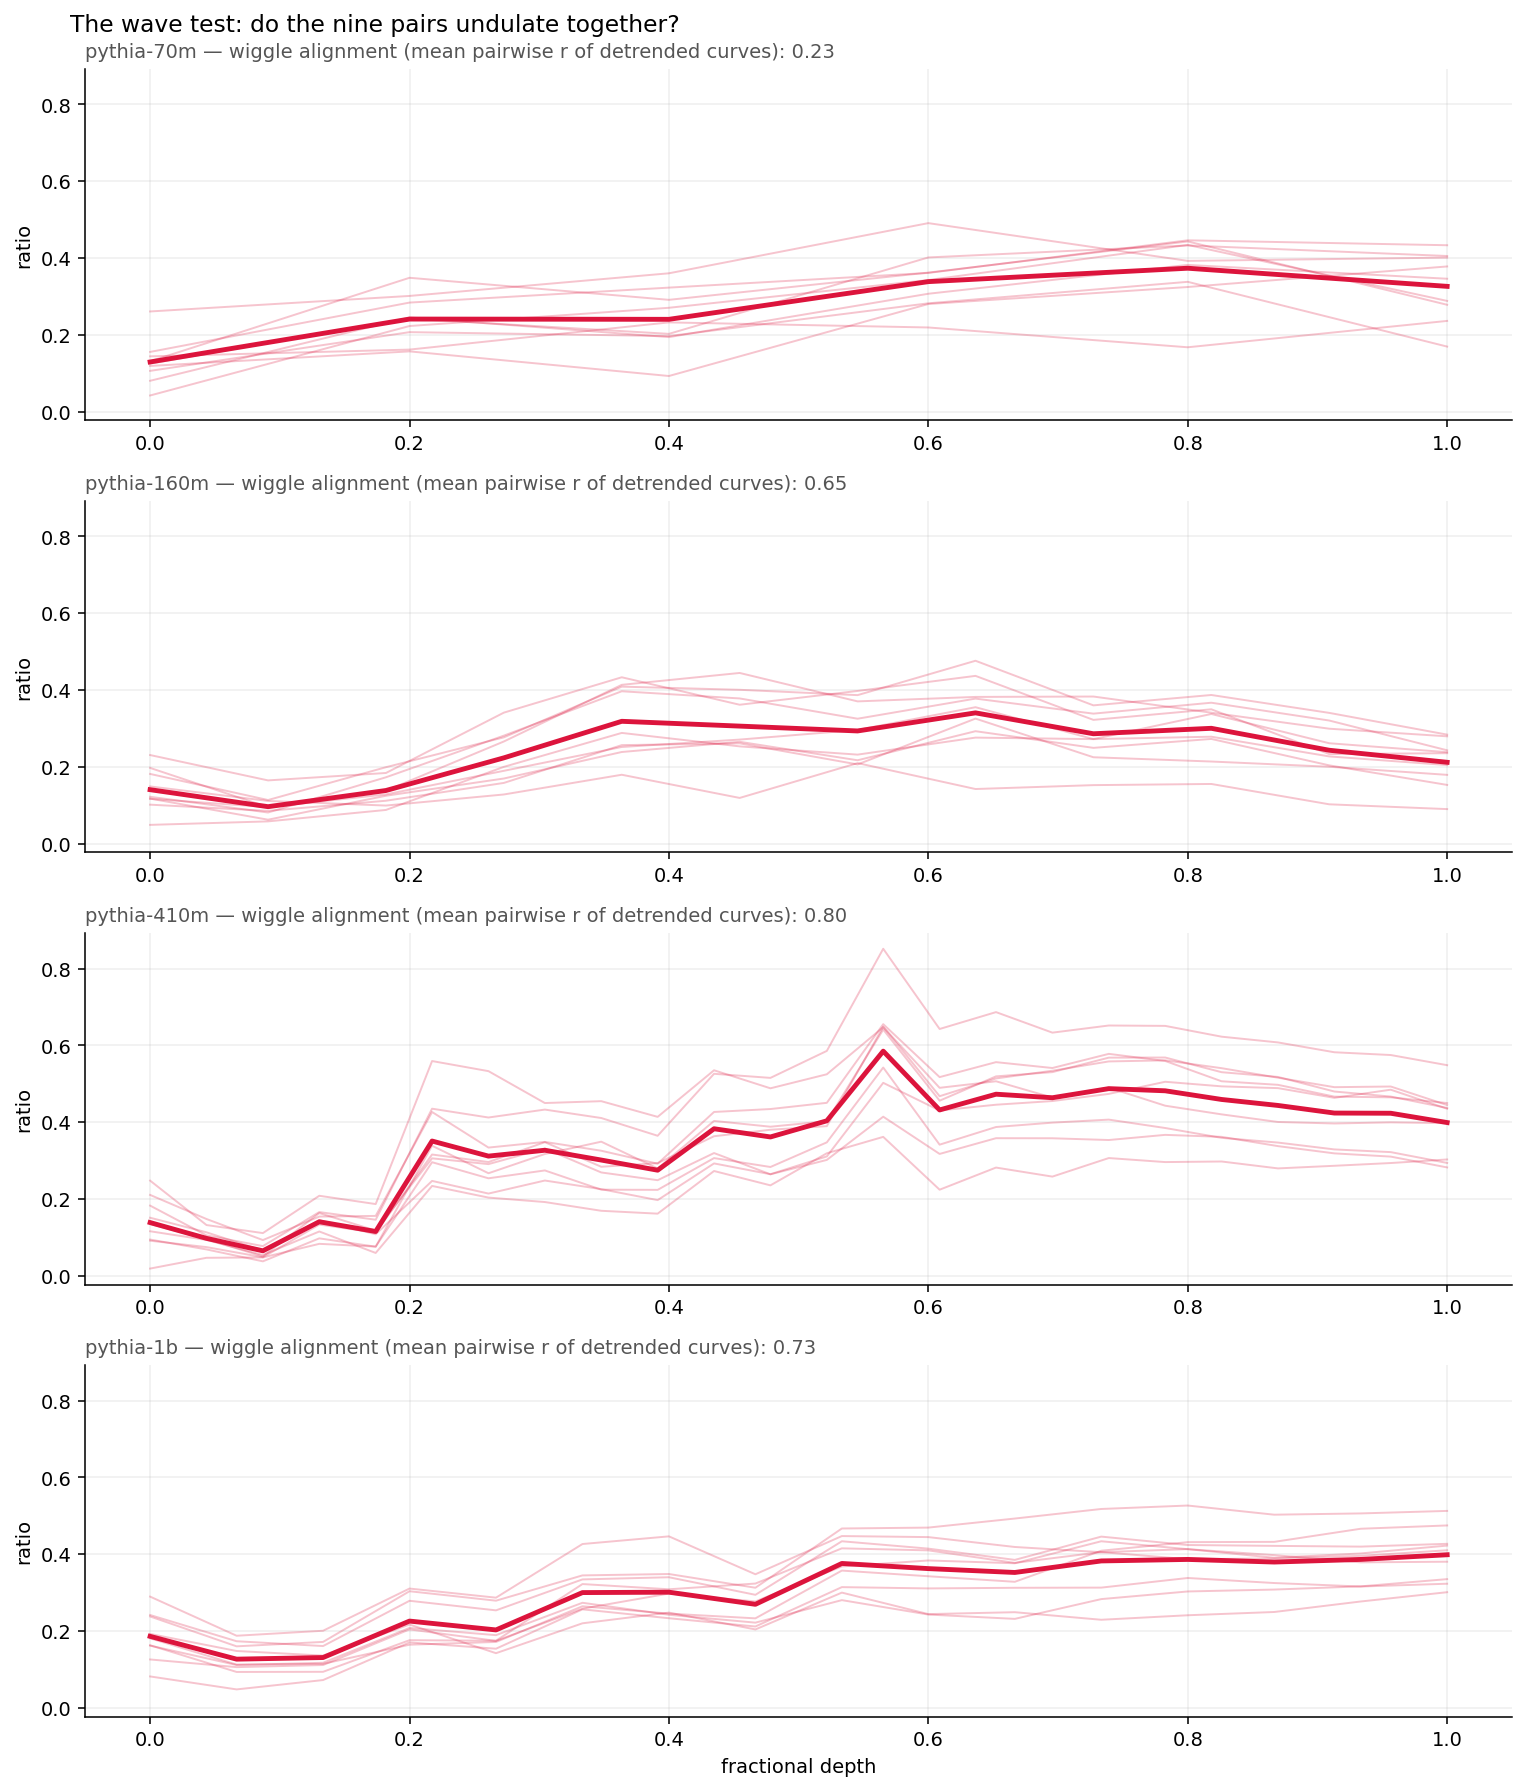

In [ ]:
import numpy as np, torch, gc
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

fig, axs = plt.subplots(4, 1, figsize=(11, 13), dpi=140, sharey=True)
fig.patch.set_facecolor('white')
fig.suptitle("The wave test: do the nine pairs undulate together?", fontsize=12, x=0.05, ha='left')

for ax, name in zip(axs, ["pythia-70m", "pythia-160m", "pythia-410m", "pythia-1b"]):
    model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
    n_layers = model.cfg.n_layers

    def resid_at(prompts, layer):
        vecs = []
        for p in prompts:
            _, c = model.run_with_cache(model.to_tokens(p))
            vecs.append(c["resid_post", layer][0].mean(dim=0).float())
        return torch.stack(vecs)

    axes_ = {}
    for L in range(n_layers):
        pa, na = resid_at(pos_matched, L), resid_at(neg_matched, L)
        a = pa.mean(0) - na.mean(0); axes_[L] = a / a.norm()

    per_pair = []
    for s_pos, s_neg in test_pairs:
        tpk, tnk = model.to_tokens(s_pos), model.to_tokens(s_neg)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        _, cpp = model.run_with_cache(tpk); _, cnn = model.run_with_cache(tnk)
        curve = []
        for L in range(n_layers):
            dvec = (cpp["resid_post", L][0] - cnn["resid_post", L][0]).float()
            axL = axes_[L]
            on  = (dvec @ axL).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ axL)[:, None] * axL[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            curve.append(on / off)
        per_pair.append(curve)
        del cpp, cnn

    P = np.array(per_pair)                      # [9, n_layers]
    x = np.linspace(0, 1, n_layers)

    # detrend each pair with its own smooth fit; what's left is its wiggle
    R = np.stack([row - np.polyval(np.polyfit(x, row, 2), x) for row in P])

    # alignment score: mean pairwise correlation of the wiggles
    cors = [np.corrcoef(R[i], R[j])[0,1] for i in range(len(R)) for j in range(i+1, len(R))]
    score = np.mean(cors)

    for row in P:
        ax.plot(x, row, color='#dc143c', alpha=0.25, lw=1)
    ax.plot(x, P.mean(0), color='#dc143c', lw=2.5)
    ax.set_title(f"{name} — wiggle alignment (mean pairwise r of detrended curves): {score:.2f}",
                 fontsize=10, loc='left', color='#555555')
    ax.set_ylabel("ratio"); ax.grid(alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

    del model, axes_
    gc.collect(); torch.cuda.empty_cache()

axs[-1].set_xlabel("fractional depth")
plt.tight_layout()
plt.savefig("wave_alignment_test.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


Verdict: the wave survives. The undulation in the depth profile is shared across sentence pairs: mean pairwise correlation of detrended per-pair curves is 0.65 (160m), 0.80 (410m), 0.73 (1B) — nine different sentences place their peaks and troughs at the same fractional depths. The wave is a property of the network’s processing, not an averaging artifact. In 70m the score is only 0.23 — with six layers there is barely room for a wave to exist, consistent with the undulation being resolvable only once depth permits. The widening claim is partially supported: 1B’s undulation is smoother and broader than 410m’s chop, but 410m’s anomalous violence complicates a clean period-vs-depth statement. Interpretation, held loosely: the shared rhythm suggests alternating processing phases — concentration onto the feature direction, then redistribution while other work is done, then re-concentration — a breathing pattern in how the network holds meaning. Caveats: n=9 pairs, one feature (sentiment), one model family; the phase structure is described, not explained.